In [1]:
import tables as tb
import numpy as np
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
from invisible_cities.core.system_of_units import *

from invisible_cities.reco.corrections import read_maps, maps_coefficient_getter, get_normalization_factor, correct_geometry_, correct_lifetime_
from invisible_cities.types.symbols import NormStrategy


In [2]:
file = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/208Tl/prod/PORT_1a/prod/sophronia_LTvalues/sophronia_*_208Tl.h5'
files = sorted(glob(file), key = lambda x: int(x.split('_')[-2]))

### We can try to filter fiducially the events in two different ways:
* Check for a certain RAD how much % of the total energy stays out, and decide based on that
* Make a comparison between the nexus max rad or the reco max rad... if the distance is very big, we supress that event. This would work for spureous SiPMs for example

In [3]:
# corr_map = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/LightTables/4bar/map_NEXT100_MC_202501.h5'
save_path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/208Tl/prod/PORT_1a/prod/events_info.h5'

In [4]:
# # for the correction by hand
# # lifetime = 50 * ms
# # maps = read_maps(corr_map)
# # get_xy_corr_fun = maps_coefficient_getter(maps.mapinfo, maps.e0)
# # # get_lt_corr_fun = maps_coefficient_getter(maps.mapinfo, maps.lt)
# # normalization   = get_normalization_factor(maps, NormStrategy.kr, None)

# mcener, recoener= pd.DataFrame([]), pd.DataFrame([])
# min_rad = 300
# max_rad = 550
# rad_step = 50

# for i, f in enumerate(files):
#     print(i)
#     mchits   = pd.read_hdf(f, 'MC/hits')
#     recohits = pd.read_hdf(f, 'RECO/Events')
#     # #by hand correction with 50 mus of lifetime
#     # geo_factor = correct_geometry_(get_xy_corr_fun(recohits.X, recohits.Y))
#     # lt_factor = correct_lifetime_(recohits.Z, lifetime)
#     # recohits['Ec_hand'] = recohits.E * normalization * geo_factor * lt_factor

#     # compute radius
#     mchits  ['rad'] = np.sqrt(mchits.x   ** 2 + mchits.y   ** 2) 
#     recohits['rad'] = np.sqrt(recohits.X ** 2 + recohits.Y ** 2) 

#     # add info of the % of the energy of the event with energy below a certain R
#     col_dict = {'Ec' : 'sum', 'E':'sum', 'rad':'max'}

#     df = recohits[['event', 'Ec', 'rad']].copy()
#     df['tot_Ec'] = df.groupby('event').Ec.transform('sum')
#     for R in np.arange(min_rad, max_rad + rad_step, rad_step)[::-1]:
#         df['rad_group'] = df['rad'].apply(lambda x: 'above' if x >= R else 'below')
#         below_sum = df[df['rad_group'] == 'below'].groupby('event')['Ec'].sum()
#         df['Ec_sum_below'] = df['event'].map(below_sum).fillna(0) #fillna for the events that have nohits below R
#         col_name = 'perc_below_{}'.format(R)
#         recohits[col_name] = df['Ec_sum_below'] / df['tot_Ec']
#         col_dict[col_name] = 'max'

#     mc_df = mchits.groupby('event_id').agg(tot_ener = ('energy', 'sum'), radius = ('rad', 'max'))
#     mcener = mcener.append(mc_df)

#     reco_df = recohits.groupby('event').agg(col_dict)
#     recoener = recoener.append(reco_df)

# recoener.to_hdf(save_path, 'summary/sophronia')
# mcener.to_hdf(save_path, 'summary/mc')

In [5]:
save_path          = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/208Tl/prod/PORT_1a/prod/events_info.h5'
save_path_LTvalues = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/208Tl/prod/PORT_1a/prod/info_soph_LTvalues.h5'
mcener = pd.read_hdf(save_path, 'summary/mc')
recoener = pd.read_hdf(save_path, 'summary/sophronia')

mcener_LT = pd.read_hdf(save_path_LTvalues, 'summary/mc')
recoener_LT = pd.read_hdf(save_path_LTvalues, 'summary/sophronia')

In [6]:
nevents_sim_per_file = 60000
nfiles = 1500

nsim = nevents_sim_per_file * nfiles

Text(0, 0.5, 'Events')

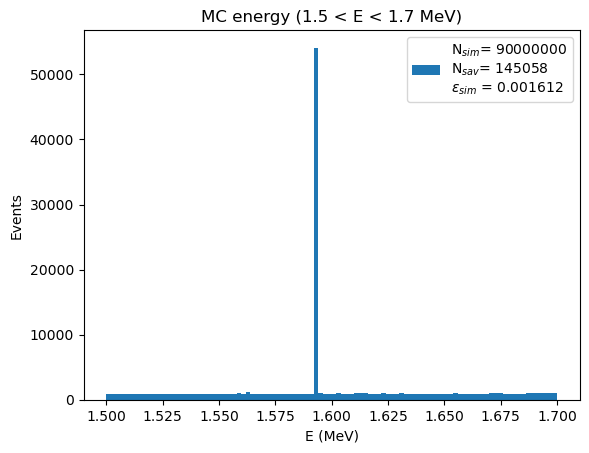

In [7]:
h = plt.hist(mcener.tot_ener, 100, (1.5, 1.7))
mc_saved_evs = int(h[0].sum())

plt.legend([r'N$_{sim}$' + '= {}\n'.format(nsim) + r'N$_{sav}$' + '= {}\n'.format(mc_saved_evs) + r'$\epsilon_{sim}$' + ' = {:.6f}'.format(mc_saved_evs / nsim)])
plt.title('MC energy (1.5 < E < 1.7 MeV)')
plt.xlabel('E (MeV)')
plt.ylabel('Events')

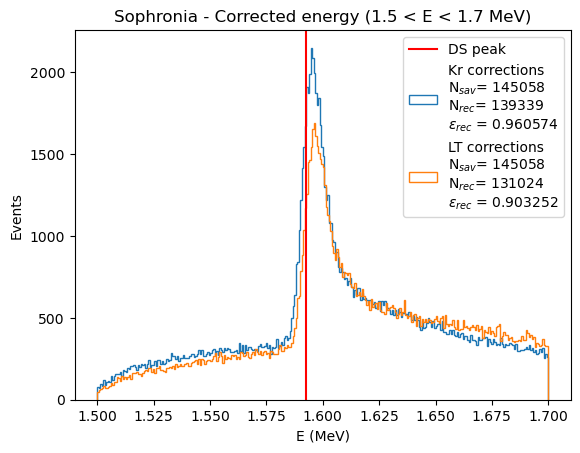

In [8]:
h = plt.hist(recoener.Ec, 300, (1.5, 1.7), histtype='step')

reco_saved_evs = h[0].sum()
plt.xlabel('E (MeV)')
plt.ylabel('Events')
plt.title('Sophronia - Corrected energy (1.5 < E < 1.7 MeV)')
# plt.axvline(x = 1.592, color = 'r', label = 'DS energy')
# plt.yscale('log')


h = plt.hist(recoener_LT.Ec, 300, (1.5, 1.7), histtype='step')

reco_saved_evs_LT = h[0].sum()
# plt.axvline(x = 1.592, color = 'r', label = 'DS energy')
# plt.yscale('log')
plt.axvline(1.5925, color = 'r')

plt.legend(['DS peak', 
            'Kr corrections\n' + r'N$_{sav}$' + '= {}\n'.format(mc_saved_evs) + r'N$_{rec}$' + '= {}\n'.format(int(reco_saved_evs)) + r'$\epsilon_{rec}$' + ' = {:.6f}'.format(reco_saved_evs / mc_saved_evs), 
            'LT corrections\n' + r'N$_{sav}$' + '= {}\n'.format(mc_saved_evs) + r'N$_{rec}$' + '= {}\n'.format(int(reco_saved_evs_LT)) + r'$\epsilon_{rec}$' + ' = {:.6f}'.format(reco_saved_evs_LT / mc_saved_evs)])


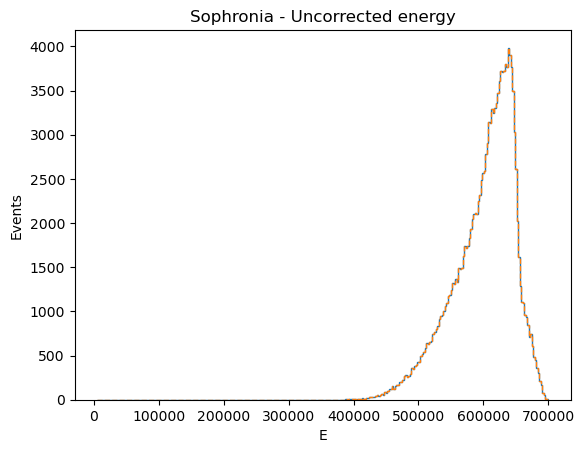

In [9]:
h = plt.hist(recoener.E, 300, histtype='step')
plt.title('Sophronia - Uncorrected energy')
plt.xlabel('E')
plt.ylabel('Events')

h = plt.hist(recoener_LT.E, 300, histtype='step', linestyle = '--')


What we should try with this now is to get lower radius (like 300) but not deleting all the events outside of them, and trying instead to pick the ones that left MOST of their energy below 300 (lets try with 0.8?)

0.7 44299
0.7999999999999999 39487
0.9 33505
1.0 8948


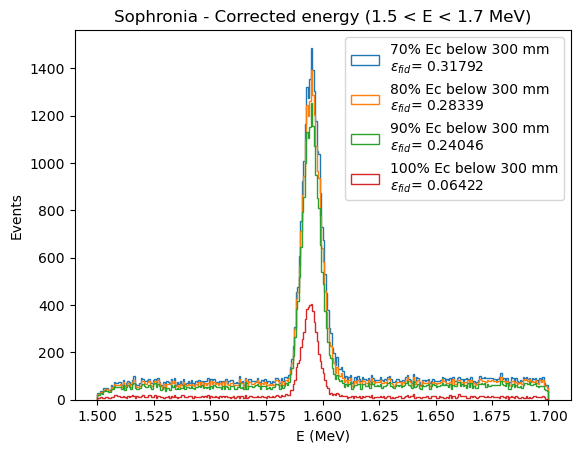

In [10]:
R = 300
for perc in np.linspace(0.7, 1, 4): #np.arange(0.7, 1, 0.1):

    df = recoener[recoener['perc_below_{}'.format(R)] >= round(perc, 1)]
    nevents = len(df[(df.Ec > 1.5) & (df.Ec < 1.7)])
    print(perc, nevents)
    h = plt.hist(df.Ec, 300, (1.5, 1.7), histtype='step', label = '{}% Ec below {} mm'.format(int(perc * 100), R) + '\n' + r'$\epsilon_{fid}$' + '= {:.5f}'.format(nevents / reco_saved_evs))
    plt.legend()
    plt.xlabel('E (MeV)')
    plt.ylabel('Events')
    plt.title('Sophronia - Corrected energy (1.5 < E < 1.7 MeV)')

    # plt.yscale('log')

60777.0
31095.0


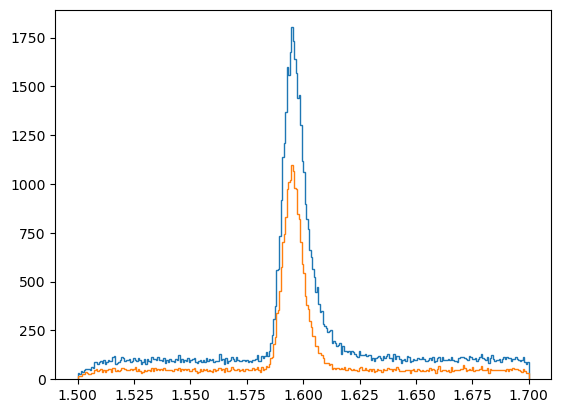

In [11]:
h = plt.hist(recoener[recoener.perc_below_400 > 0.97].Ec, 300, (1.5, 1.7), histtype='step')
print(sum(h[0]))
h = plt.hist(recoener[recoener.perc_below_400 == 1].Ec, 300, (1.5, 1.7), histtype='step')
print(sum(h[0]))

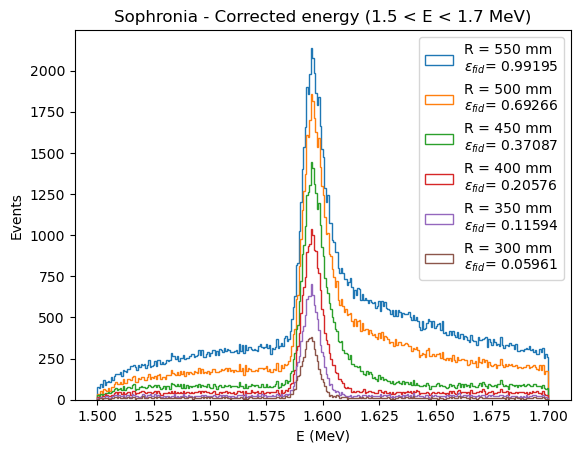

In [12]:
for r in np.arange(300, 600, 50)[::-1]:
    df = recoener[recoener.rad < r]
    nevents = len(df[(df.Ec > 1.5) & (df.Ec < 1.7)])
    h = plt.hist(df.Ec, 300, (1.5, 1.7), histtype='step', label = 'R = {} mm'.format(r) + '\n' + r'$\epsilon_{fid}$' + '= {:.5f}'.format(nevents / reco_saved_evs))
    plt.legend()
    plt.xlabel('E (MeV)')
    plt.ylabel('Events')
    plt.title('Sophronia - Corrected energy (1.5 < E < 1.7 MeV)')

    # plt.yscale('log')


In [13]:
from scipy.optimize import curve_fit
from scipy.integrate import quad

#trashy function, very hard coded
def fit_and_plot_peaks_resolution(data, fun, nbins, plotrange, fitrange, initial_params, bounds, title, density = True):
    y, x = np.histogram(data, nbins, range = plotrange, density = density)
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y = x[fit_mask], y[fit_mask[:-1]]
    params, cov = curve_fit(fun, fit_x, fit_y, p0=initial_params, bounds = bounds, maxfev = 2000)
    a, mu, sigma, m, c = params[0], params[1], params[2], params[3], params[4]
    yfit = fun(fit_x, a, mu, sigma, m, c)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((cov[2, 2] / sigma) **2 + (cov[1, 1]/mu)**2)

    legend_string = r'$\mu={:.3f} \pm {:.3e}$'.format(mu, cov[1,1]) + '\n' + \
                    r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, cov[2,2]) + '\n' + \
                    r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR)
    plt.hist(data, nbins, range = plotrange, histtype='step', density = density)
    plt.plot(fit_x, yfit, 'r-', label = legend_string)
    plt.legend()
    plt.xlabel('E (MeV)')
    if density:
        plt.ylabel('Probability density (1 / MeV)')
    else:
        plt.ylabel('Events')
    plt.title(title)
    plt.grid()
    plt.show()
    return params, R

In [16]:
from scipy.optimize import curve_fit
from scipy.integrate import quad


def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu) / sigma) ** 2 / 2)

def expon(x, m, c):
    return m *np.exp(-x/c)

def peak_fit(x, a, mu, sigma, m, c):
    return gauss(x, a, mu, sigma) + expon(x, m, c)

#trashy function, very hard coded
def fit_and_plot_peaks(data, peak_fit, gauss, expon, nbins, plotrange, fitrange, initial_params, bounds, title, density = True):
    y, x = np.histogram(data, nbins, range = plotrange, density = density)
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y = x[fit_mask], y[fit_mask[:-1]]
    params, cov = curve_fit(peak_fit, fit_x, fit_y, p0=initial_params, bounds = bounds, maxfev = 2000)
    a, mu, sigma, m, c = params[0], params[1], params[2], params[3], params[4]

    N_sig = a * sigma * np.sqrt(2 * np.pi) #from gaussian integral formula + adding the a term multiplying
    N_bkg, _ = quad(lambda x: expon(x, m, c), fit_x[0], fit_x[-1])

    N_tot, _ = quad(lambda x: peak_fit(x, a, mu, sigma, m, c), fit_x[0], fit_x[-1])

    # Need to scale integral value depending on binning method
    if density:
        N_sig *= len(data)
        N_bkg *= len(data)
        N_tot *= len(data)
    else:
        bwidth = fit_x[1] - fit_x[0]
        N_sig /= bwidth
        N_bkg /= bwidth
        N_tot /= bwidth

    y_fit = peak_fit(fit_x, a, mu, sigma, m, c)
    y_gauss = gauss(fit_x, a, mu, sigma)
    y_expon = expon(fit_x, m, c)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((cov[2, 2] / sigma) **2 + (cov[1, 1]/mu)**2)

    legend_string = r'Entries' + '$ = {:d}$ events'.format(len(data)) + '\n' + \
                    r'$\mu={:.3f} \pm {:.3e}$'.format(mu, cov[1,1]) + '\n' + \
                    r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, cov[2,2]) + '\n' + \
                    r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR) + '\n' + \
                    r'$N_{tot}$' + '$ = {:d}$ events'.format(int(N_tot))
    plt.hist(data, nbins, range = plotrange, histtype='step', density = density)
    plt.plot(fit_x, y_fit, 'b-', label = legend_string)
    plt.plot(fit_x, y_gauss, 'r-', label = r'$N_{sig}$' + '$ = {:d}$ events'.format(int(N_sig)))
    plt.plot(fit_x, y_expon, 'g-', label = r'$N_{bkg}$' + '$ = {:d}$ events'.format(int(N_bkg)))
    plt.legend()
    plt.xlabel('E (MeV)')
    if density:
        plt.ylabel('Probability density (1 / MeV)')
    else:
        plt.ylabel('Events')
    plt.title(title)
    plt.grid()
    plt.show()
    return params, R


# METER ERRORES A NUMERO DE EVENTOS

0.7


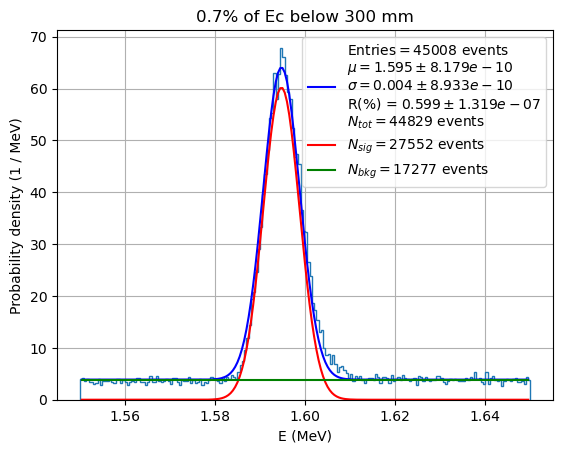

0.7999999999999999


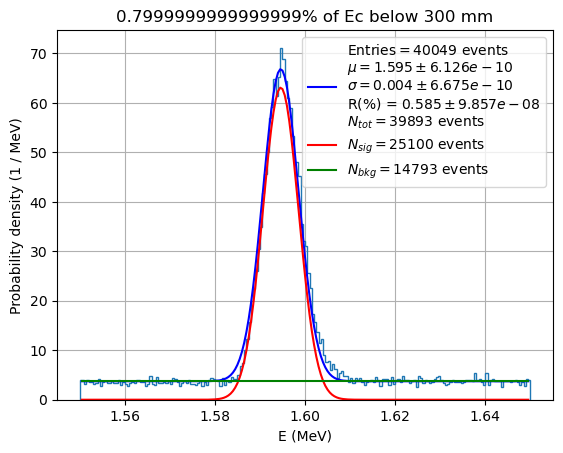

0.9


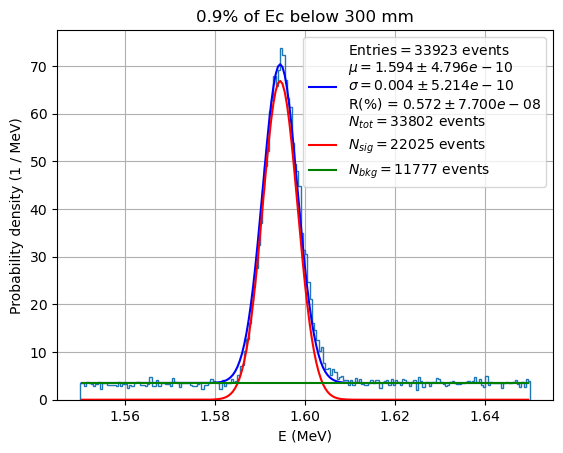

1.0


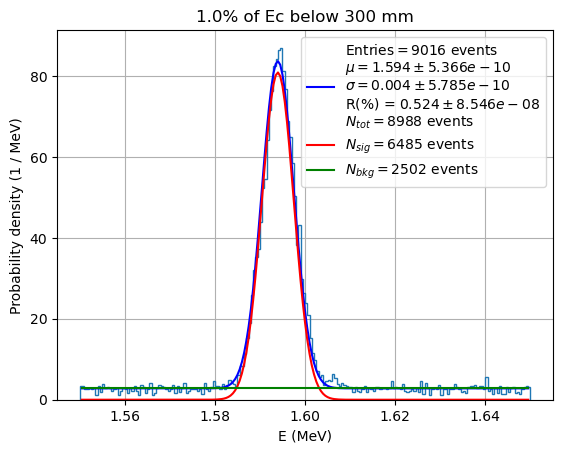

In [17]:
nbins = 200
plotrange = (1.550, 1.65) #(1.55, 1.65)
fitrange = (1.550, 1.65) #(1.55, 1.65)
initial_params = [300, 1.59, 0.02, 1, 7]
bounds = ([0, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])


R = 300
for perc in np.linspace(0.7, 1, 4): #np.arange(0.7, 1, 0.1):
    title = '{}% of Ec below {} mm'.format(perc, R)
    print(perc)
    df = recoener[recoener['perc_below_{}'.format(R)] >= round(perc, 1)]
    ds_5bar = fit_and_plot_peaks(df.Ec, peak_fit, gauss, expon, nbins, plotrange, fitrange, initial_params, bounds, title, density = True)



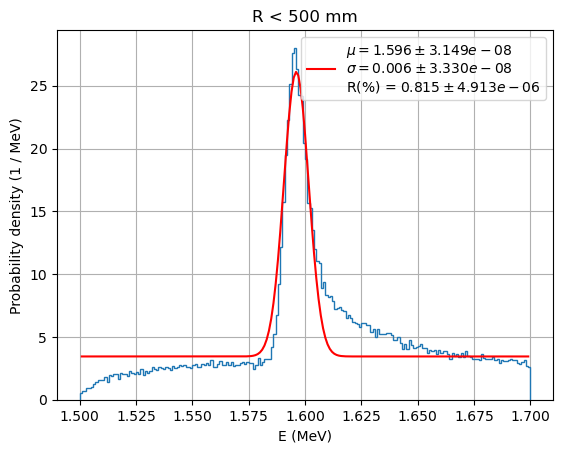

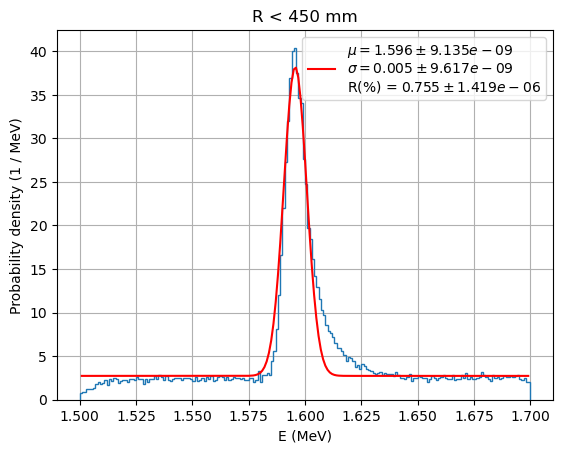

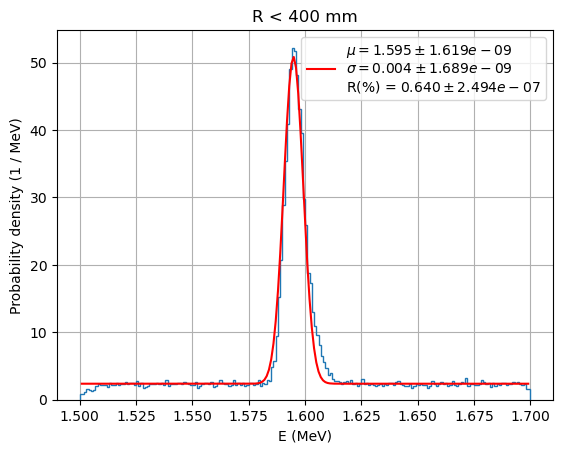

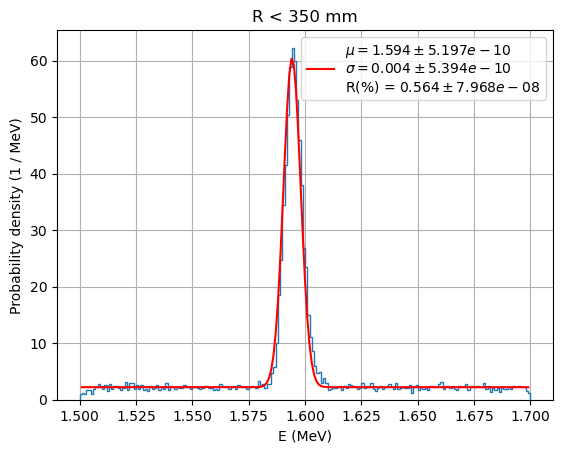

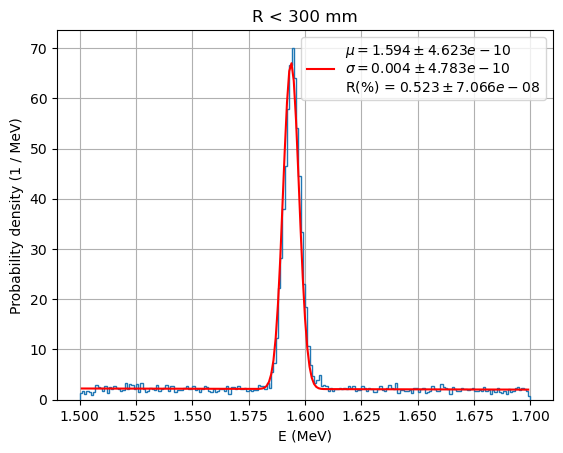

In [15]:
nbins = 200
plotrange = (1.5, 1.7) #(1.55, 1.65)
fitrange = (1.5, 1.7) #(1.55, 1.65)
initial_params = [300, 1.59, 0.02, 1, 7]
bounds = ([0, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])

for r in np.arange(300, 550, 50)[::-1]:
    title = 'R < {} mm'.format(r)

    ds_5bar = fit_and_plot_peaks(recoener[recoener.rad < r].Ec, gauss, nbins, plotrange, fitrange, initial_params, bounds, title, density = True)



In [ ]:
from scipy.stats import skewnorm
import scipy.special as special
from scipy.optimize import curve_fit


def skewnorm_func(x, a, mu, sigma):
    return skewnorm.pdf(x, a, loc = mu, scale = sigma)

def error_func(x, mu, sigma):
    pas = (x - mu)/(np.sqrt(2)*sigma)
    return special.erfc(pas)

def sig_func(x, ns, a, mu, sigma, C1, C2):
    return ns * (skewnorm_func(x, a, mu, sigma) + C1*error_func(x, mu, sigma) + C2)

def bkg_func(x, nb, tau):
    '''
    Function describing the background, an exponential with scaling from Nb and tau
    '''
    return nb*np.exp(-x/tau)

def fit_peak_function(x, ns, a, mu, sigma, C1, C2, nb, tau):
    return sig_func(x, ns, a, mu, sigma, C1, C2) + bkg_func(x, nb, tau)



def fit_and_plot_peaks_skew(data, fun, nbins, plotrange, fitrange, initial_params, bounds, title):
    y, x = np.histogram(data, nbins, range = plotrange, density = True)
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y = x[fit_mask], y[fit_mask[:-1]]
    params, cov = curve_fit(fun, fit_x, fit_y, p0=initial_params, bounds = bounds, maxfev = 2000)
    ns, a, mu, sigma, C1, C2, nb, tau = params[0], params[1], params[2], params[3], params[4], params[5], params[6], params[7]
    yfit = fun(fit_x, ns, a, mu, sigma, C1, C2, nb, tau)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((cov[2, 2] / sigma) **2 + (cov[1, 1]/mu)**2)

    legend_string = r'$\mu={:.3f} \pm {:.3e}$'.format(mu, cov[1,1]) + '\n' + \
                    r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, cov[2,2]) + '\n' + \
                    r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR)
    plt.hist(data, nbins, range = plotrange, histtype='step', density = True)
    plt.plot(fit_x, yfit, 'r-', label = legend_string)
    plt.legend()
    plt.xlabel('E (MeV)')
    plt.title(title)
    plt.grid()
    plt.show()
    return params, R


In [ ]:
nbins = 100
plotrange = (1.55, 1.65)
fitrange = (1.55, 1.65)
initial_params = [300, 10, 1.59, 0.02, 0, 0, 1000, 100]
bounds = ([0, 0, 0, 0, -np.inf, -np.inf, 0, 0], [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf])
title = 'Skewnorm fit'

ds_5bar = fit_and_plot_peaks_skew(recoener[recoener.radius < 350].tot_Ec, fit_peak_function, nbins, plotrange, fitrange, initial_params, bounds, title)
ds_5bar